In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



In [4]:
df_dataset = pd.read_csv(r"\\zkh\appdata\RTDicom\Projectline_HNC_modelling\Users\Daniel MacRae\1. MultiTox_HNC\Dataset\MT_dataset_with_all_structs.csv", delimiter=';')

df_dataset['Year'] = df_dataset["RTSTART"].str.split('-').str[0].astype(int)

In [63]:
df_dataset

,PatientID,Split,DB,RTSTART,Geslacht,Leeftijd,Loctum,Loctum2,Technique,Inplancode,...,N2,N3,"Roken_Ja, in verleden","Roken_Ja, nog steeds",Roken_Nee,Chemoradiation,Bioradiation,Concurrent_Chemo_or_Bioradiation,Protons,Year
0,10125,train_val,REDCAP,2018-07-02,0,0.55,Palatum molle + uvula,Pharynx,VMAT,HH 35 6x-F,...,0,0,1,0,0,0,0,0,0,2018
1,10152,train_val,REDCAP,2013-08-12,1,0.59,Tonsil + fossa + pharynxboog + glossotonsillai...,Pharynx,IMRT,HH IMRT 35 5x PET_CT(CBCT),...,1,0,0,1,0,1,0,1,0,2013
2,10279,train_val,CITOR143,2017-10-23,1,0.67,Supraglottisch,Larynx,VMAT,HH VMAT 35 5x CBCT,...,1,0,1,0,0,1,0,1,0,2017
3,10348,test,CITOR750,2009-05-25,1,0.81,Glottisch,Larynx,3D-CRT,-1,...,0,0,0,0,1,0,0,0,0,2009
4,10619,train_val,CITOR750,2012-08-13,1,0.64,Tonsil + fossa + pharynxboog + glossotonsillai...,Pharynx,IMRT,-1,...,1,0,1,0,0,1,0,1,0,2012
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1368,99777,train_val,RECAP,2023-04-12,1,0.71,Tonsil + fossa + pharynxboog + glossotonsillai...,Pharynx,Protons,HH 35 5pw-P,...,1,0,1,0,0,0,0,0,1,2023
1369,99798,train_val,REDCAP,2019-07-24,1,0.71,Supraglottisch,Larynx,VMAT,HH 35 5x-F,...,1,0,1,0,0,0,0,0,0,2019
1370,99820,train_val,CITOR750,2010-01-11,1,0.76,Hypopharynxachterwand (vanaf nivo vallecula),Pharynx,IMRT,-1,...,0,0,1,0,0,0,1,1,0,2010
1371,99870,train_val,RECAP,2023-07-05,1,0.60,Tonsil + fossa + pharynxboog + glossotonsillai...,Pharynx,Protons,HH 35 5pw-P,...,1,0,1,0,0,0,0,0,1,2023


In [14]:
df_dataset.Technique.replace({'IMPT' : 'Protons'}, inplace=True)

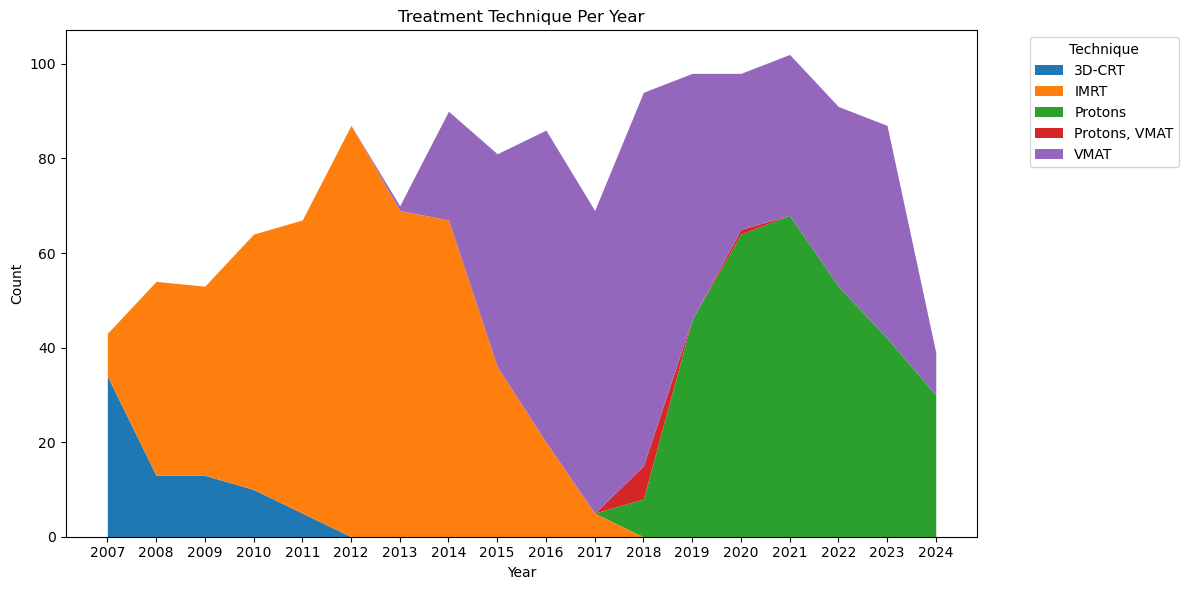

In [107]:
# Group by Year and Technique, then count occurrences
technique_per_year = df_dataset.groupby(['Year', 'Technique']).size().unstack(fill_value=0)

# Plot the stacked area chart
technique_per_year.plot(kind='area', stacked=True, figsize=(12, 6), lw=0) # , edgecolor=None)
plt.title('Treatment Technique Per Year')
plt.xlabel('Year')
plt.xticks(ticks=range(technique_per_year.index.min(), technique_per_year.index.max() + 1, 1))
plt.ylabel('Count')
plt.legend(title='Technique', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

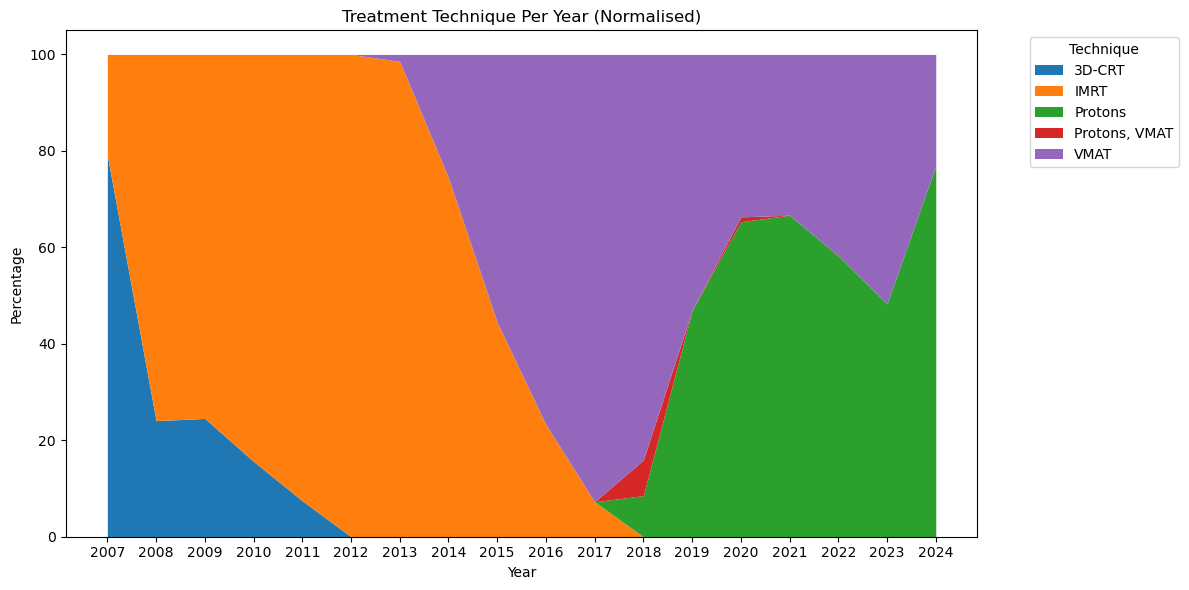

In [90]:
# Group by Year and Technique, then count occurrences
technique_per_year = df_dataset.groupby(['Year', 'Technique']).size().unstack(fill_value=0)

# Normalize each year to a total of 100
technique_per_year = technique_per_year.div(technique_per_year.sum(axis=1), axis=0) * 100

# Plot the stacked area chart
technique_per_year.plot(kind='area', stacked=True, figsize=(12, 6), lw=0) # , edgecolor=None)
plt.title('Treatment Technique Per Year (Normalised)')
plt.xlabel('Year')
plt.xticks(ticks=range(technique_per_year.index.min(), technique_per_year.index.max() + 1, 1))
plt.ylabel('Percentage')
plt.legend(title='Technique', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Default matplotlib colors: ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']


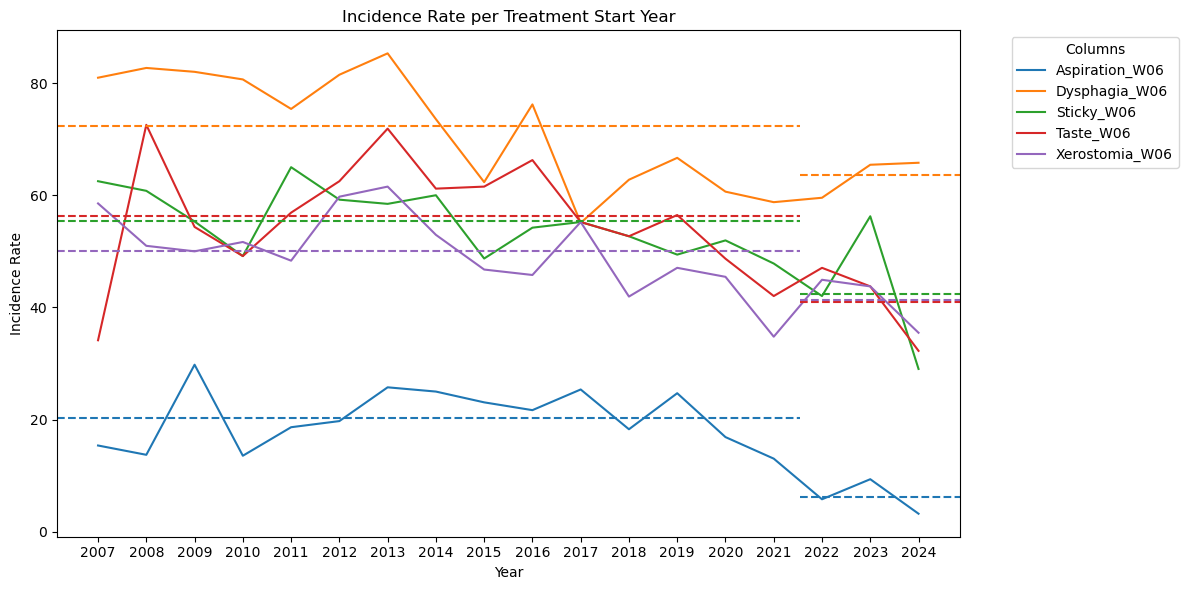

In [119]:

# Define the columns of interest
toxicities = ['Aspiration', 'Dysphagia', 'Sticky', 'Taste', 'Xerostomia']

endpoint_columns = [f'{toxicity}_W06' for toxicity in toxicities]
baseline_columns = [f'{toxicity}_W01' for toxicity in toxicities]

columns_of_interest = endpoint_columns

incidence_rate = df_dataset.groupby('Year')[columns_of_interest].apply(
    lambda x: (x == 1).sum() / ((x == 1).sum() + (x == 0).sum()) * 100
)

# Calculate the mean incidence rate up until 2021 and after 2021
mean_before_2021 = incidence_rate.loc[:2021].mean()
mean_after_2021 = incidence_rate.loc[2022:].mean()
# Plot the incidence rate
ax = incidence_rate.plot(kind='line', figsize=(12, 6))

default_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
print("Default matplotlib colors:", default_colors)

# Add horizontal dashed lines for the mean incidence rates
for colour, column in zip(default_colors, columns_of_interest):
    ax.axhline(mean_before_2021[column], xmin=0, xmax=(2021 - incidence_rate.index.min()) / (incidence_rate.index.max() - incidence_rate.index.min()), linestyle='--',  color=colour)
    ax.axhline(mean_after_2021[column], xmin=(2021 - incidence_rate.index.min()) / (incidence_rate.index.max() - incidence_rate.index.min()), xmax=1, linestyle='--', color=colour)

plt.title('Incidence Rate per Treatment Start Year')
plt.xlabel('Year')
plt.ylabel('Incidence Rate')
plt.xticks(ticks=range(technique_per_year.index.min(), technique_per_year.index.max() + 1, 1))
plt.legend(title='Columns', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

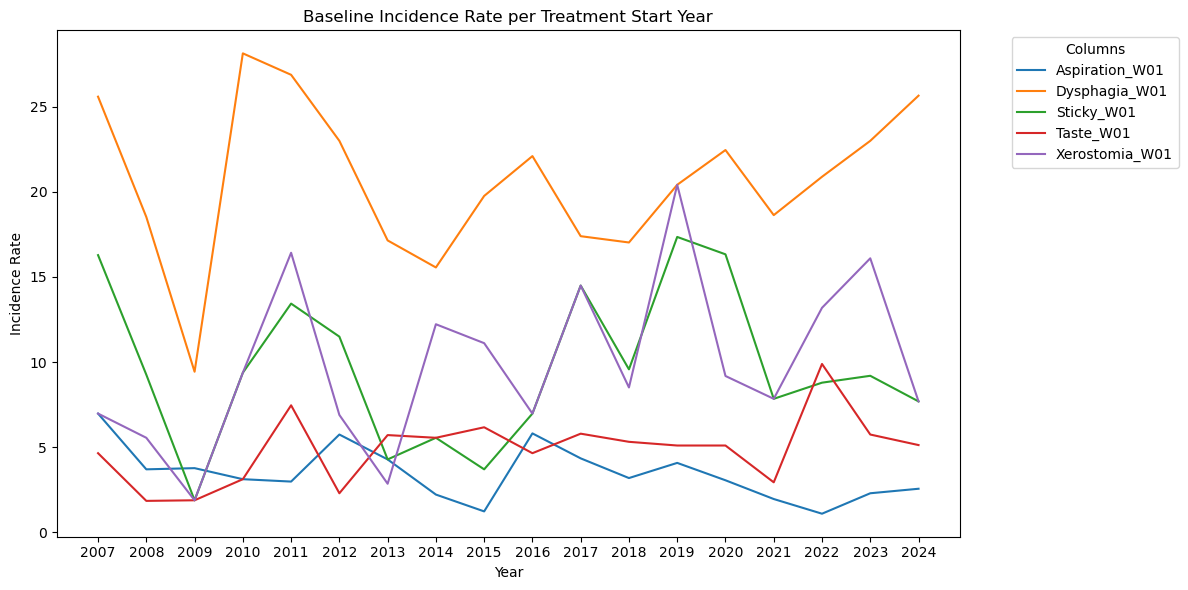

In [32]:
columns_of_interest = baseline_columns

# Filter out rows with -1 values in the columns of interest
#filtered_df = df_dataset[df_dataset[columns_of_interest].apply(lambda x: ~x.isin([-1])).all(axis=1)]

# Calculate the incidence rate per year for each column
incidence_rate = df_dataset.groupby('Year')[columns_of_interest].apply(
    lambda x: (x == 1).sum() / ((x == 1).sum() + (x == 0).sum()) * 100
)

# Plot the incidence rate
incidence_rate.plot(kind='line', figsize=(12, 6))
plt.title('Baseline Incidence Rate per Treatment Start Year')
plt.xlabel('Year')
plt.ylabel('Incidence Rate')
plt.xticks(ticks=range(technique_per_year.index.min(), technique_per_year.index.max() + 1, 1))
plt.legend(title='Columns', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

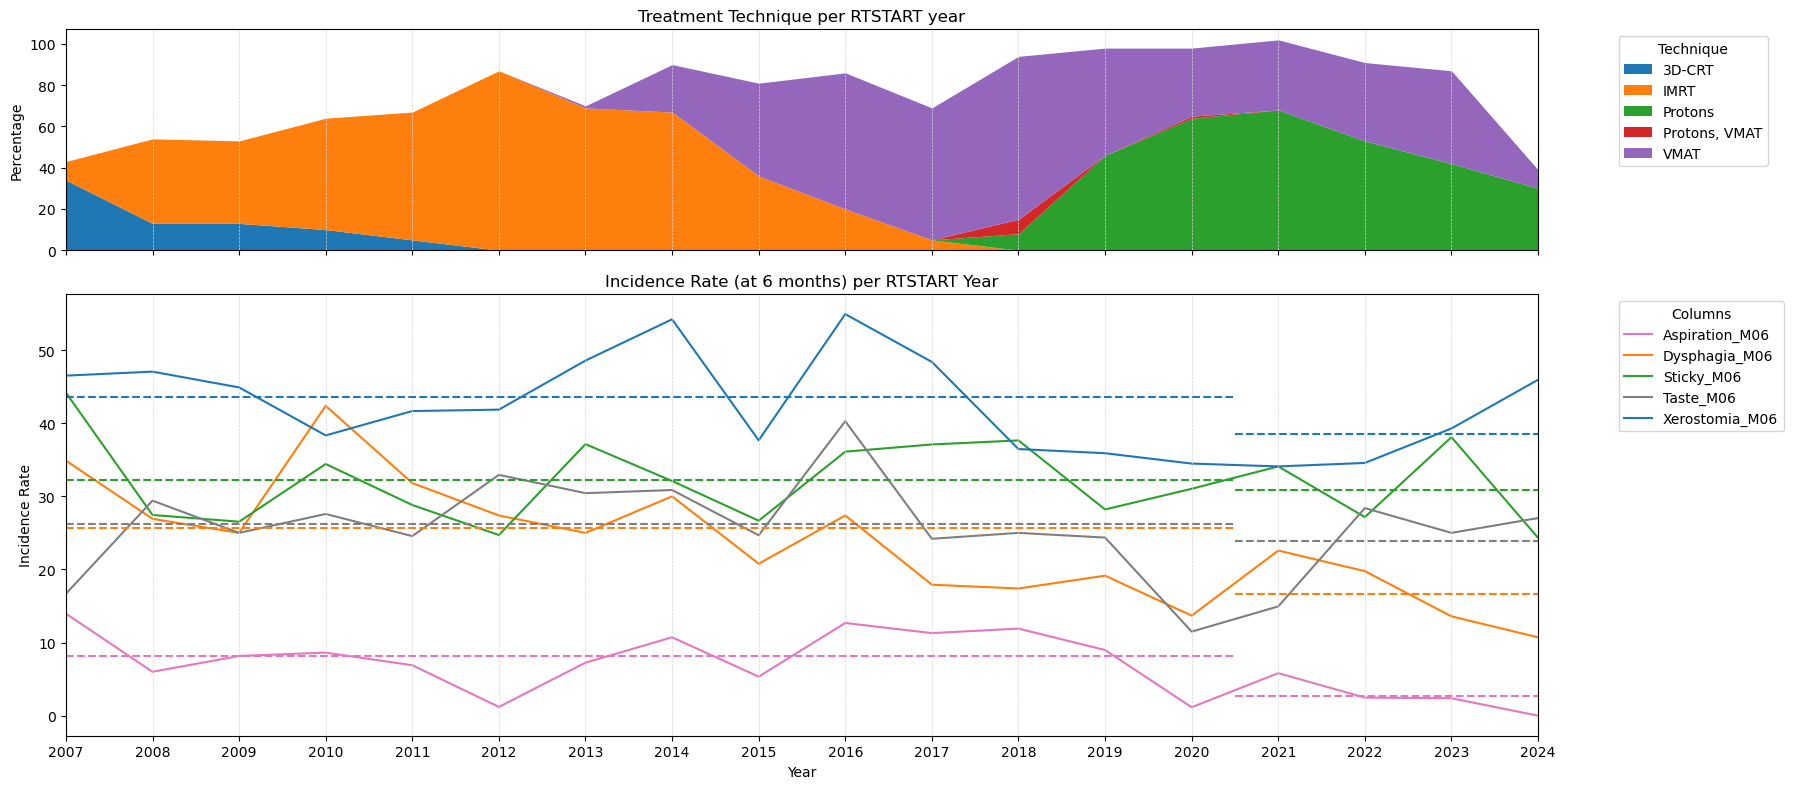

In [155]:
from matplotlib.colors import ListedColormap

colours = ['tab:pink',  'tab:orange', 'tab:green', 'tab:grey', 'tab:blue']
# Create a ListedColormap from the colours list
colormap = ListedColormap(colours)

columns_of_interest = [f"{endpoint}_M06" for endpoint in toxicities]    # NOTE: define the incicence rate columns of interest here !!

# Create a figure with two subplots stacked vertically
fig, axes = plt.subplots(2, 1, figsize=(18, 8), sharex=True, height_ratios=[1,2])

# Plot the stacked area chart for treatment technique per year (normalized)
technique_per_year.plot(kind='area', stacked=True, ax=axes[0], lw=0)
axes[0].set_title('Treatment Technique per RTSTART year')
axes[0].set_ylabel('Percentage')
axes[0].legend(title='Technique', bbox_to_anchor=(1.05, 1), loc='upper left')


# Calculate the incidence rate per year for each column
incidence_rate = df_dataset.groupby('Year')[columns_of_interest].apply(
    lambda x: (x == 1).sum() / ((x == 1).sum() + (x == 0).sum()) * 100
)


# Plot the incidence rate per year for each column
incidence_rate.plot(kind='line', ax=axes[1], colormap=colormap)
axes[1].set_title('Incidence Rate (at 6 months) per RTSTART Year')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Incidence Rate')
axes[1].legend(title='Columns', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1].set_xticks(range(technique_per_year.index.min(), technique_per_year.index.max() + 1, 1))
axes[0].set_xticks(range(technique_per_year.index.min(), technique_per_year.index.max() + 1, 1))

axes[1].set_xlim(technique_per_year.index.min(), technique_per_year.index.max())
for year in range(technique_per_year.index.min(), technique_per_year.index.max() + 1):
    axes[0].axvline(x=year, color='lightgrey', linestyle='--', linewidth=0.5)
    axes[1].axvline(x=year, color='lightgrey', linestyle='--', linewidth=0.5)

cutoff_year = 2020.5
mean_before_cutoff = incidence_rate.loc[:cutoff_year].mean()
mean_after_cutoff = incidence_rate.loc[cutoff_year:].mean()


# Add horizontal dashed lines for the mean incidence rates
for colour, column in zip(colours, columns_of_interest):
    axes[1].axhline(mean_before_cutoff[column], xmin=0, xmax=(cutoff_year - incidence_rate.index.min()) / (incidence_rate.index.max() - incidence_rate.index.min()), linestyle='--',  color=colour)
    axes[1].axhline(mean_after_cutoff[column], xmin=(cutoff_year - incidence_rate.index.min()) / (incidence_rate.index.max() - incidence_rate.index.min()), xmax=2024, linestyle='--', color=colour)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

# Delta toxicity scores

Default matplotlib colors: ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']


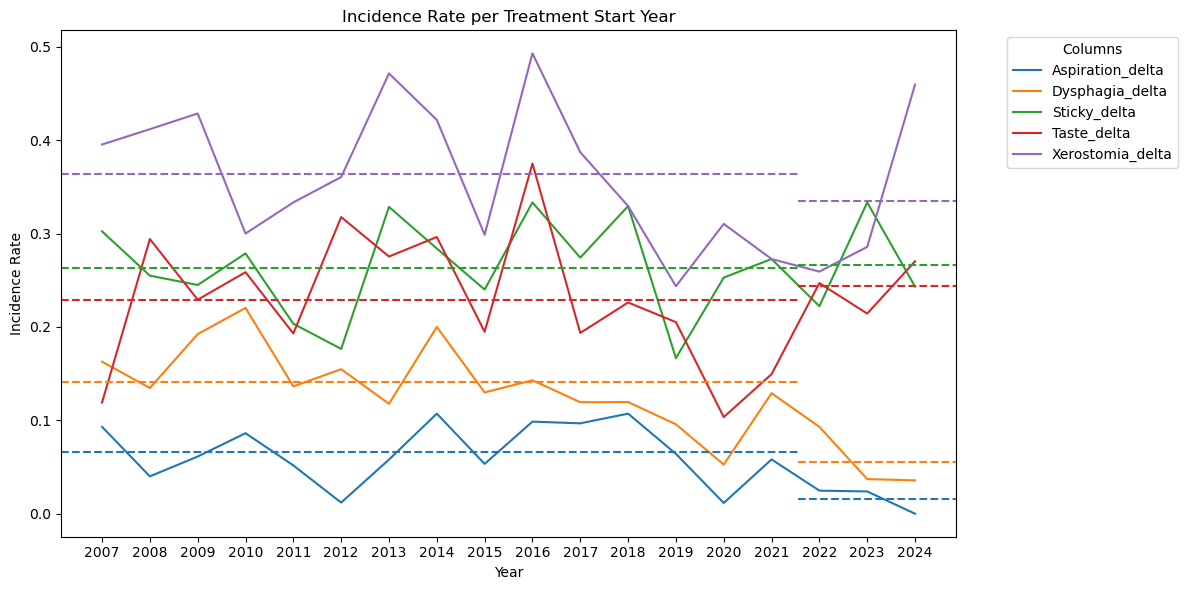

In [105]:

# Define the columns of interest
toxicities = ['Aspiration', 'Dysphagia', 'Sticky', 'Taste', 'Xerostomia']

endpoint_columns = [f'{toxicity}_M06' for toxicity in toxicities]
baseline_columns = [f'{toxicity}_W01' for toxicity in toxicities]

delta_columns = []

for tox in toxicities:
    # mask out -1 values in the columns of interest
    mask = df_dataset[[f'{tox}_M06', f'{tox}_W01']].apply(lambda x: ~x.isin([-1])).all(axis=1)
    # Calculate the delta for each toxicity, using the mask to filter out -1 values
    col_name = f'{tox}_delta'
    delta_columns.append(col_name)
    df_dataset[col_name] = np.where(mask, df_dataset[f'{tox}_M06'] - df_dataset[f'{tox}_W01'], np.nan)

columns_of_interest = delta_columns

incidence_rate = df_dataset.groupby('Year')[columns_of_interest].apply(
    lambda x: (x > 0).sum() / ((~x.isna()).sum()) 
)

# Calculate the mean incidence rate up until 2021 and after 2021
mean_before_2021 = incidence_rate.loc[:2021].mean()
mean_after_2021 = incidence_rate.loc[2022:].mean()
# Plot the incidence rate
ax = incidence_rate.plot(kind='line', figsize=(12, 6))

default_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
print("Default matplotlib colors:", default_colors)

# Add horizontal dashed lines for the mean incidence rates
for colour, column in zip(default_colors, columns_of_interest):
    ax.axhline(mean_before_2021[column], xmin=0, xmax=(2021 - incidence_rate.index.min()) / (incidence_rate.index.max() - incidence_rate.index.min()), linestyle='--',  color=colour)
    ax.axhline(mean_after_2021[column], xmin=(2021 - incidence_rate.index.min()) / (incidence_rate.index.max() - incidence_rate.index.min()), xmax=1, linestyle='--', color=colour)

plt.title('Incidence Rate per Treatment Start Year')
plt.xlabel('Year')
plt.ylabel('Incidence Rate')
plt.xticks(ticks=range(technique_per_year.index.min(), technique_per_year.index.max() + 1, 1))
plt.legend(title='Columns', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()